# Ms. Pac-Man — случайный поиск и восхождение на вершину

In [1]:
%pip install -q "gymnasium[atari]>=1.0,<2" "ale-py>=0.9"

## Импорты

In [2]:
# Импорты

import random

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Регистрируем Atari-среды.
try:
    gym.register_envs(
        ale_py
    )
except Exception:
    pass


print(
    "Gymnasium:",
    gym.__version__
)

print(
    "PyTorch:",
    torch.__version__
)

Gymnasium: 1.3.0
PyTorch: 2.11.0+cu128


## Среда Ms. Pac-Man

Берём:

```text
ALE/MsPacman-ram-v5
```

`full_action_space=False` оставляет только осмысленные для игры действия.

Для Ms. Pac-Man это 9 действий, поэтому условие задания
**«больше 4 действий»** выполняется.

`obs_type=ram` даёт состояние размерности 128.

In [3]:
# Создание среды

ENV_ID = "ALE/MsPacman-v5"


env = gym.make(
    ENV_ID,

    obs_type="ram",

    full_action_space=False,

    frameskip=4,

    repeat_action_probability=0.0,
)


n_state = (
    env.observation_space
    .shape[0]
)

n_action = (
    env.action_space.n
)


print(
    "Среда:",
    ENV_ID
)

print(
    "Размер состояния:",
    n_state
)

print(
    "Количество действий:",
    n_action
)

print(
    "Действия:",
    env.unwrapped.get_action_meanings()
)


assert n_action > 4

Среда: ALE/MsPacman-v5
Размер состояния: 128
Количество действий: 9
Действия: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


## Нормализация состояния

RAM Atari содержит значения от `0` до `255`.

Перед умножением на веса переводим их в диапазон примерно:

```text
-0.5 ... 0.5
```

In [4]:
# Подготовка состояния

def prepare_state(
    observation,
):
    state = torch.tensor(
        observation,
        dtype=torch.float32,
    )

    state = (
        state / 255.0
        - 0.5
    )

    return state

## Линейная стратегия

Как и в уроке:

```text
state × weight -> оценки действий -> argmax
```

Матрица весов имеет форму:

```text
128 × 9
```

In [5]:
# Выбор действия

def select_action(
    state,
    weight,
):
    values = torch.matmul(
        state,
        weight,
    )

    action = torch.argmax(
        values
    ).item()

    return int(
        action
    )

## Один эпизод

`run_episode` получает веса стратегии, проходит один эпизод игры
и возвращает полное вознаграждение.

Число шагов ограничиваем, чтобы обучение в Colab не занимало
слишком много времени.

In [6]:
# Один эпизод

MAX_STEPS = 2500


def run_episode(
    weight,
    seed=SEED,
    max_steps=MAX_STEPS,
):

    observation, info = env.reset(
        seed=seed
    )


    total_reward = 0.0


    for step in range(
        max_steps
    ):

        state = prepare_state(
            observation
        )


        action = select_action(
            state,
            weight,
        )


        (
            observation,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )


        total_reward += float(
            reward
        )


        if (
            terminated
            or truncated
        ):
            break


    return total_reward

## Оценка весов

Чтобы случайность одного старта меньше влияла на результат,
каждую матрицу весов проверяем на двух одинаковых seed.

В качестве качества берём среднее вознаграждение.

In [7]:
# Оценка стратегии

TRAIN_SEEDS = [
    100,
    101,
]


def evaluate_weight(
    weight,
    seeds=TRAIN_SEEDS,
):

    rewards = [
        run_episode(
            weight,
            seed=seed,
        )
        for seed
        in seeds
    ]


    return float(
        np.mean(
            rewards
        )
    )

## Базовый случайный агент

Сначала посмотрим результат агента, который вообще не использует веса,
а на каждом шаге выбирает случайное действие.

In [8]:
# Случайный агент

def run_random_agent(
    seed=SEED,
    max_steps=MAX_STEPS,
):

    observation, info = env.reset(
        seed=seed
    )


    total_reward = 0.0


    for step in range(
        max_steps
    ):

        action = (
            env.action_space
            .sample()
        )


        (
            observation,
            reward,
            terminated,
            truncated,
            info,
        ) = env.step(
            action
        )


        total_reward += float(
            reward
        )


        if (
            terminated
            or truncated
        ):
            break


    return total_reward


random_agent_rewards = [
    run_random_agent(
        seed=seed
    )
    for seed
    in range(
        10,
        15,
    )
]


print(
    "Награды:",
    random_agent_rewards
)

print(
    "Среднее:",
    np.mean(
        random_agent_rewards
    )
)

Награды: [230.0, 420.0, 170.0, 290.0, 240.0]
Среднее: 270.0


# Стратегия случайного поиска

Как в уроке:

1. Создаём случайную матрицу весов.
2. Запускаем агента.
3. Получаем полное вознаграждение.
4. Если результат лучше предыдущего — сохраняем веса.
5. Следующий кандидат снова создаётся случайно.

Для Atari используем меньше эпизодов, чем для CartPole,
так как один эпизод существенно тяжелее.

In [9]:
# Случайный поиск

N_RANDOM_SEARCH = 40


best_random_reward = (
    -float(
        "inf"
    )
)

best_random_weight = None

random_search_rewards = []

random_search_best = []


for episode in range(
    N_RANDOM_SEARCH
):

    # Новые случайные веса
    weight = torch.rand(
        n_state,
        n_action,
    )


    total_reward = evaluate_weight(
        weight
    )


    random_search_rewards.append(
        total_reward
    )


    if (
        total_reward
        > best_random_reward
    ):

        best_random_reward = (
            total_reward
        )

        best_random_weight = (
            weight.clone()
        )


    random_search_best.append(
        best_random_reward
    )


    if (
        episode == 0
        or (
            episode + 1
        ) % 5 == 0
    ):

        print(
            f"Эпизод {episode + 1:02d} | "
            f"reward={total_reward:.1f} | "
            f"best={best_random_reward:.1f}"
        )

Эпизод 01 | reward=270.0 | best=270.0
Эпизод 05 | reward=230.0 | best=290.0
Эпизод 10 | reward=410.0 | best=650.0
Эпизод 15 | reward=210.0 | best=650.0
Эпизод 20 | reward=200.0 | best=650.0
Эпизод 25 | reward=80.0 | best=650.0
Эпизод 30 | reward=320.0 | best=650.0
Эпизод 35 | reward=60.0 | best=700.0
Эпизод 40 | reward=210.0 | best=700.0


In [10]:
# Результат случайного поиска

print(
    "Лучшее вознаграждение:",
    best_random_reward
)

print(
    "Среднее вознаграждение:",
    np.mean(
        random_search_rewards
    )
)

Лучшее вознаграждение: 700.0
Среднее вознаграждение: 261.5


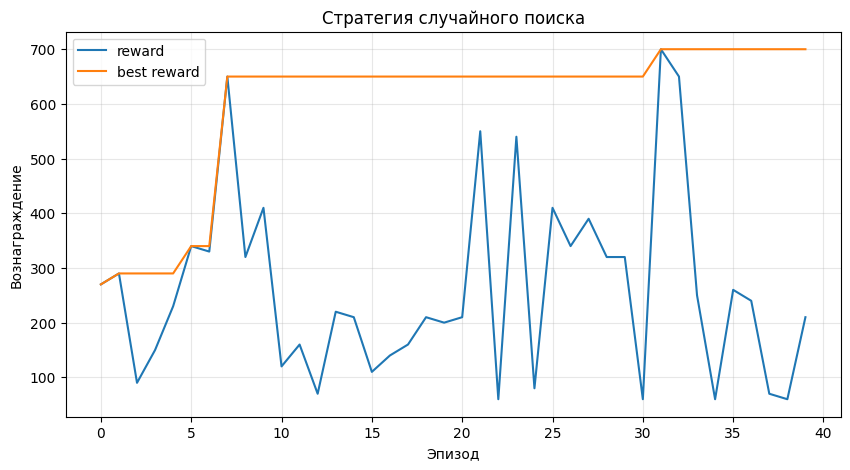

In [11]:
# График случайного поиска

plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    random_search_rewards,
    label="reward",
)


plt.plot(
    random_search_best,
    label="best reward",
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Вознаграждение"
)

plt.title(
    "Стратегия случайного поиска"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

# Восхождение на вершину

Теперь агент использует накопленный опыт.

Алгоритм из урока:

1. Берём текущие лучшие веса.
2. Добавляем к ним случайный шум.
3. Проверяем новые веса.
4. Если reward улучшился — сохраняем их.
5. При улучшении уменьшаем шум в 2 раза, но не ниже `0.0001`.
6. При ухудшении увеличиваем шум в 2 раза, но не выше `2`.

То есть поиск идёт не по всему пространству весов,
а в окрестности уже найденного решения.

In [12]:
# Восхождение на вершину

N_HILL_CLIMB = 80


best_hill_weight = torch.rand(
    n_state,
    n_action,
)


best_hill_reward = evaluate_weight(
    best_hill_weight
)


noise_scale = 0.01


hill_rewards = []

hill_best = []

hill_noise = []


for episode in range(
    N_HILL_CLIMB
):

    # Шум вокруг лучших весов
    noise = torch.randn(
        n_state,
        n_action,
    )


    weight = (
        best_hill_weight
        + noise_scale
        * noise
    )


    total_reward = evaluate_weight(
        weight
    )


    hill_rewards.append(
        total_reward
    )


    if (
        total_reward
        > best_hill_reward
    ):

        best_hill_reward = (
            total_reward
        )

        best_hill_weight = (
            weight.clone()
        )


        # Улучшение ->
        # уменьшаем шаг поиска
        noise_scale = max(
            noise_scale / 2,
            0.0001,
        )


    else:

        # Ухудшение ->
        # увеличиваем область поиска
        noise_scale = min(
            noise_scale * 2,
            2.0,
        )


    hill_best.append(
        best_hill_reward
    )

    hill_noise.append(
        noise_scale
    )


    if (
        episode == 0
        or (
            episode + 1
        ) % 5 == 0
    ):

        print(
            f"Эпизод {episode + 1:02d} | "
            f"reward={total_reward:.1f} | "
            f"best={best_hill_reward:.1f} | "
            f"noise={noise_scale:.4f}"
        )

Эпизод 01 | reward=1000.0 | best=1000.0 | noise=0.0050
Эпизод 05 | reward=190.0 | best=1000.0 | noise=0.0800
Эпизод 10 | reward=170.0 | best=1000.0 | noise=2.0000
Эпизод 15 | reward=70.0 | best=1000.0 | noise=2.0000
Эпизод 20 | reward=120.0 | best=1000.0 | noise=2.0000
Эпизод 25 | reward=60.0 | best=1000.0 | noise=2.0000
Эпизод 30 | reward=60.0 | best=1000.0 | noise=2.0000
Эпизод 35 | reward=520.0 | best=1000.0 | noise=2.0000
Эпизод 40 | reward=70.0 | best=1000.0 | noise=2.0000
Эпизод 45 | reward=210.0 | best=1000.0 | noise=2.0000
Эпизод 50 | reward=60.0 | best=1000.0 | noise=2.0000
Эпизод 55 | reward=60.0 | best=1000.0 | noise=2.0000
Эпизод 60 | reward=240.0 | best=1000.0 | noise=2.0000
Эпизод 65 | reward=210.0 | best=1000.0 | noise=2.0000
Эпизод 70 | reward=700.0 | best=1090.0 | noise=2.0000
Эпизод 75 | reward=70.0 | best=1090.0 | noise=2.0000
Эпизод 80 | reward=110.0 | best=1090.0 | noise=2.0000


In [13]:
# Результат восхождения

print(
    "Лучшее вознаграждение:",
    best_hill_reward
)

print(
    "Среднее вознаграждение:",
    np.mean(
        hill_rewards
    )
)

print(
    "Финальный шум:",
    noise_scale
)

Лучшее вознаграждение: 1090.0
Среднее вознаграждение: 283.625
Финальный шум: 2.0


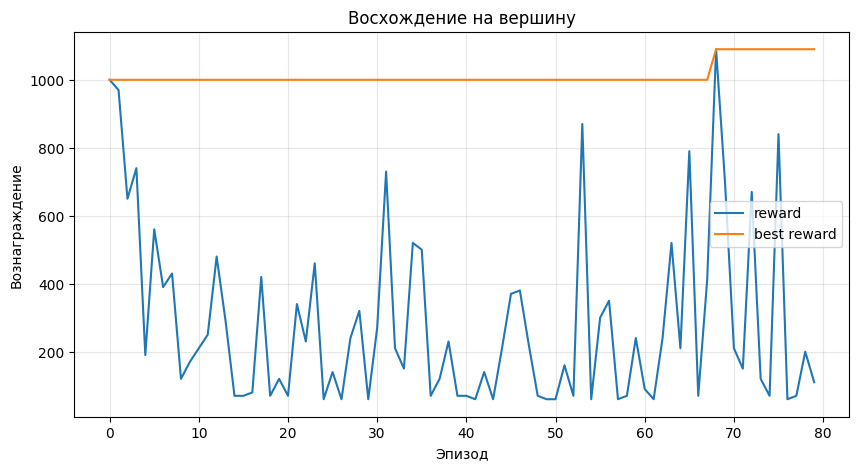

In [14]:
# График восхождения

plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    hill_rewards,
    label="reward",
)


plt.plot(
    hill_best,
    label="best reward",
)


plt.xlabel(
    "Эпизод"
)

plt.ylabel(
    "Вознаграждение"
)

plt.title(
    "Восхождение на вершину"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## Проверка лучших стратегий

Теперь обе найденные стратегии проверяем на **новых seed**,
которые не использовались во время поиска.

In [15]:
# Тестовые эпизоды

TEST_SEEDS = list(
    range(
        200,
        210,
    )
)


random_test_rewards = [
    run_episode(
        best_random_weight,
        seed=seed,
    )
    for seed
    in TEST_SEEDS
]


hill_test_rewards = [
    run_episode(
        best_hill_weight,
        seed=seed,
    )
    for seed
    in TEST_SEEDS
]


results = pd.DataFrame(
    {
        "seed": TEST_SEEDS,

        "random_search": (
            random_test_rewards
        ),

        "hill_climbing": (
            hill_test_rewards
        ),
    }
)


display(
    results
)

,seed,random_search,hill_climbing
0,200,700.0,1090.0
1,201,700.0,1090.0
2,202,700.0,1090.0
3,203,700.0,1090.0
4,204,700.0,1090.0
5,205,700.0,1090.0
6,206,700.0,1090.0
7,207,700.0,1090.0
8,208,700.0,1090.0
9,209,700.0,1090.0


In [16]:
# Средние результаты

summary = pd.DataFrame(
    {
        "Стратегия": [
            "Случайный поиск",
            "Восхождение на вершину",
        ],

        "Средний reward": [
            np.mean(
                random_test_rewards
            ),

            np.mean(
                hill_test_rewards
            ),
        ],

        "Максимальный reward": [
            np.max(
                random_test_rewards
            ),

            np.max(
                hill_test_rewards
            ),
        ],
    }
)


display(
    summary
)

,Стратегия,Средний reward,Максимальный reward
0,Случайный поиск,700.0,700.0
1,Восхождение на вершину,1090.0,1090.0


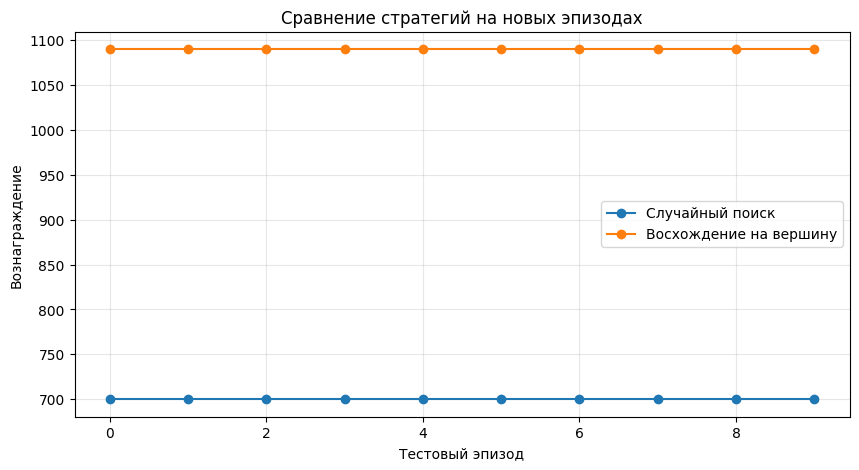

In [17]:
# Сравнение стратегий

plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    random_test_rewards,
    marker="o",
    label="Случайный поиск",
)


plt.plot(
    hill_test_rewards,
    marker="o",
    label="Восхождение на вершину",
)


plt.xlabel(
    "Тестовый эпизод"
)

plt.ylabel(
    "Вознаграждение"
)

plt.title(
    "Сравнение стратегий на новых эпизодах"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## Сохранение лучших весов

In [18]:
# Сохранение

torch.save(
    best_random_weight,
    "/content/"
    "mspacman_random_search.pt",
)


torch.save(
    best_hill_weight,
    "/content/"
    "mspacman_hill_climbing.pt",
)


print(
    "Лучшие веса сохранены"
)

Лучшие веса сохранены


## Результат

Для задания была выбрана игра **Ms. Pac-Man** из Gym Atari.

В сокращённом пространстве у игры 9 действий, поэтому условие
больше 4 действий выполняется.

Для состояния использована Atari RAM размерности 128.

Это позволило применить тот же линейный подход, который использовался
в уроке для CartPole:

```text
state @ weight -> action
```

Были реализованы две стратегии:

- **случайный поиск** — на каждом эпизоде создаётся новая матрица весов,
  после чего сохраняется лучший результат;
- **восхождение на вершину** — новые веса получаются изменением уже лучших
  весов небольшим адаптивным шумом.

При восхождении на вершину коэффициент шума изменяется в зависимости
от качества нового решения:

```text
улучшение -> noise / 2
ухудшение -> noise * 2
```

с ограничением от `0.0001` до `2`.

В конце лучшие стратегии проверяются на новых эпизодах,
после чего сравниваются их средние и максимальные вознаграждения.

Из-за сложности Atari результат может заметно отличаться между запусками,
но восхождение на вершину использует информацию предыдущих эпизодов,
тогда как случайный поиск каждый раз начинает поиск весов заново.